#  Week 3: Model Training & Selection

In this phase, we build and compare multiple machine learning models to predict daily sales.

##  Objectives
- Train baseline and advanced models
- Evaluate using MAE and RMSE
- Identify the best-performing model

##  Models Used
- Linear Regression (baseline)
- Random Forest Regressor
- XGBoost Regressor (primary model)
- Prophet (time-series benchmark)

##  Important
- Time-series split is used (no random shuffle)
- Models are trained only on past data

In [29]:
# ── CELL 1: Imports ──────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBRegressor
from prophet import Prophet
import pickle
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

print(" All libraries imported!")

 All libraries imported!


##  Step 2: Load Data & Prepare Training Sets

We load the feature-engineered dataset created in Week 2 and split it into training and testing sets.

###  Time-Based Split
We use a **date-based split** to simulate real-world forecasting:
- Train → Past data
- Test → Future unseen data

###  Feature & Target Separation
- Features (X) → input variables
- Target (y) → sales

###  Important:
- No random split (prevents data leakage)
- Ensures realistic model evaluation

In [2]:
# ── CELL 2: Load Engineered Data ────────────────────────────

df = pd.read_csv('../outputs/engineered_features.csv', parse_dates=['date'])

SPLIT_DATE = '2017-07-01'

train_df = df[df['date'] < SPLIT_DATE].copy()
test_df  = df[df['date'] >= SPLIT_DATE].copy()

# Feature columns
FEATURE_COLS = [c for c in df.columns if c not in ['date', 'sales']]
TARGET = 'sales'

X_train = train_df[FEATURE_COLS]
y_train = train_df[TARGET]

X_test  = test_df[FEATURE_COLS]
y_test  = test_df[TARGET]

print(f"Training features: {X_train.shape}")
print(f"Test features:     {X_test.shape}")

Training features: (1613, 49)
Test features:     (184, 49)


In [3]:
print("\n🧪 Data Validation:")
print("Train date range:", train_df['date'].min(), "→", train_df['date'].max())
print("Test date range: ", test_df['date'].min(), "→", test_df['date'].max())

print("\nMissing values check:")
print("Train NaNs:", X_train.isnull().sum().sum())
print("Test NaNs: ", X_test.isnull().sum().sum())


🧪 Data Validation:
Train date range: 2013-01-30 00:00:00 → 2017-06-30 00:00:00
Test date range:  2017-07-01 00:00:00 → 2017-12-31 00:00:00

Missing values check:
Train NaNs: 0
Test NaNs:  0


In [4]:
train_df.to_csv('../outputs/train_model_data.csv', index=False)
test_df.to_csv('../outputs/test_model_data.csv', index=False)

print("Train/Test datasets saved!")

Train/Test datasets saved!


## Step 3: Model Evaluation Function

We define a reusable function to evaluate model performance.

###  Metrics Used:
- **MAE (Mean Absolute Error)**
  → Average prediction error

- **RMSE (Root Mean Squared Error)**
  → Penalizes large errors more heavily

###  Why This Matters:
- Standardizes evaluation across models
- Makes comparison easier
- Improves code reusability

---

In [28]:
# ── CELL 3: Evaluation Helper Function ──────────────────────

def evaluate_model(name, y_true, y_pred):
    """Calculates and prints MAE and RMSE for a model."""

    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    print(f"\n{'─'*40}")
    print(f" {name}")
    print(f"   MAE  : {mae:>10.2f}  (avg error in units)")
    print(f"   RMSE : {rmse:>10.2f}  (penalizes big errors more)")
    print(f"{'─'*40}")

    return {'model': name, 'MAE': round(mae, 2), 'RMSE': round(rmse, 2)}

# Store results for comparison
results = []

In [6]:
predictions = {}

##  Step 4: Model 1 — Linear Regression (Baseline)

We start with a simple Linear Regression model as a baseline.

###  Purpose:
- Establish a performance benchmark
- Understand linear relationships in data

###  Why Baseline Matters:
Before using complex models, we need a simple reference point.

###  Limitation:
Linear Regression assumes:
- Linear relationships
- No complex interactions

 Time-series data is usually non-linear, so this model sets the minimum performance level.

In [27]:
# ── CELL 4: MODEL 1 — Linear Regression (Baseline) ──────────

print(" Training Model 1: Linear Regression (Baseline)")

lr = LinearRegression()
lr.fit(X_train, y_train)

lr_preds = lr.predict(X_test)

# Ensure no negative predictions
lr_preds = np.maximum(lr_preds, 0)

res = evaluate_model("Linear Regression (Baseline)", y_test, lr_preds)
results.append(res)

 Training Model 1: Linear Regression (Baseline)

────────────────────────────────────────
📊 Linear Regression (Baseline)
   MAE  :       0.00  (avg error in units)
   RMSE :       0.00  (penalizes big errors more)
────────────────────────────────────────


In [26]:
coef_df = pd.DataFrame({
    'feature': FEATURE_COLS,
    'coefficient': lr.coef_
}).sort_values(by='coefficient', key=abs, ascending=False)

print(" Top 10 Influential Features:")
display(coef_df.head(10))

 Top 10 Influential Features:


,feature,coefficient
20,sales_diff,3.333333e-01
28,lag_diff_14,3.333333e-01
27,lag_diff_7,3.333333e-01
23,lag_7,3.333333e-01
24,lag_14,3.333333e-01
22,lag_1,3.333333e-01
4,year,1.434685e-13
7,is_weekend,1.207730e-13
17,is_friday,7.595798e-14
11,dow_sin,4.828489e-14


##  Step 5: Model 2 — Random Forest Regressor

Random Forest is an ensemble model that builds multiple decision trees and averages their predictions.

###  Why Random Forest?
- Captures non-linear relationships
- Handles complex feature interactions
- More robust than Linear Regression

###  Key Parameters:
- n_estimators → number of trees
- max_depth → limits tree complexity
- min_samples_split / leaf → prevents overfitting

###  Expectation:
Random Forest should outperform Linear Regression by capturing:
- Lag relationships
- Seasonal patterns
- Feature interactions

In [25]:
# ── CELL 5: MODEL 2 — Random Forest ─────────────────────────

print("\n Training Model 2: Random Forest Regressor")

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=3,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)

# Ensure non-negative predictions
rf_preds = np.maximum(rf_preds, 0)

res = evaluate_model("Random Forest Regressor", y_test, rf_preds)
results.append(res)


 Training Model 2: Random Forest Regressor

────────────────────────────────────────
📊 Random Forest Regressor
   MAE  :       0.54  (avg error in units)
   RMSE :       0.92  (penalizes big errors more)
────────────────────────────────────────


In [24]:
feat_imp = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': rf.feature_importances_
}).sort_values(by='importance', ascending=False)

print("Top 10 Important Features (Random Forest):")
display(feat_imp.head(10))

Top 10 Important Features (Random Forest):


,feature,importance
21,sales_pct_change,0.202198
22,lag_1,0.147959
35,rolling_mean_14,0.139970
20,sales_diff,0.111023
30,lag_ratio_14,0.074966
24,lag_14,0.060949
39,rolling_mean_28,0.042477
47,ewm_14,0.038943
29,lag_ratio_7,0.033845
44,ema_14,0.032855


##  Step 6: Model 3 — XGBoost (Primary Model)

XGBoost is a powerful gradient boosting algorithm widely used in production systems.

###  Why XGBoost?
- Handles non-linear relationships
- Captures complex feature interactions
- Works extremely well with tabular data

###  Time-Series Cross Validation
We use **TimeSeriesSplit** to:
- Respect chronological order
- Prevent data leakage
- Simulate real-world forecasting

###  Goal:
Achieve the lowest MAE and RMSE among all models.

In [11]:
# ── CELL 6: MODEL 3 — XGBoost with TimeSeriesSplit ──────────

print("\n⚡ Training Model 3: XGBoost with Time-Series CV")

# TimeSeriesSplit (used later for tuning if needed)
tscv = TimeSeriesSplit(n_splits=5)

xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

xgb_preds = xgb.predict(X_test)

# Ensure non-negative predictions
xgb_preds = np.maximum(xgb_preds, 0)

res = evaluate_model("XGBoost", y_test, xgb_preds)
results.append(res)


⚡ Training Model 3: XGBoost with Time-Series CV

────────────────────────────────────────
📊 XGBoost
   MAE  :       0.53  (avg error in units)
   RMSE :       0.75  (penalizes big errors more)
────────────────────────────────────────


In [12]:
xgb_imp = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': xgb.feature_importances_
}).sort_values(by='importance', ascending=False)

print(" Top 10 Features (XGBoost):")
display(xgb_imp.head(10))

 Top 10 Features (XGBoost):


,feature,importance
44,ema_14,0.203578
35,rolling_mean_14,0.132061
7,is_weekend,0.091528
21,sales_pct_change,0.086538
46,ewm_7,0.072254
20,sales_diff,0.062387
30,lag_ratio_14,0.056521
22,lag_1,0.051558
29,lag_ratio_7,0.039657
39,rolling_mean_28,0.038802


##  Step 8: Model Comparison & Leaderboard

We compare all trained models using evaluation metrics.

###  Metrics:
- MAE → Average prediction error
- RMSE → Penalizes large errors

###  Goal:
Identify the best-performing model for deployment.

### Insight:
Lower MAE & RMSE → Better model performance

In [23]:
# ── CELL 8: Model Comparison Table ──────────────────────────

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('MAE')
results_df['Rank'] = range(1, len(results_df) + 1)

print("\n MODEL LEADERBOARD:")
display(results_df[['Rank', 'model', 'MAE', 'RMSE']])

print(f"\n Best model: {results_df.iloc[0]['model']}")
print(f"   MAE:  {results_df.iloc[0]['MAE']}")
print(f"   RMSE: {results_df.iloc[0]['RMSE']}")


 MODEL LEADERBOARD:


,Rank,model,MAE,RMSE
0,1,Linear Regression (Baseline),0.00,0.00
2,2,XGBoost,0.53,0.75
1,3,Random Forest Regressor,0.54,0.92



 Best model: Linear Regression (Baseline)
   MAE:  0.0
   RMSE: 0.0


##  Step 9: Model Performance Visualization

We visualize model performance using bar charts.

###  Why Visualization?
- Makes comparison intuitive
- Helps stakeholders understand results quickly

###  Metrics Compared:
- MAE → Average error
- RMSE → Penalizes large errors

Lower values indicate better performance.

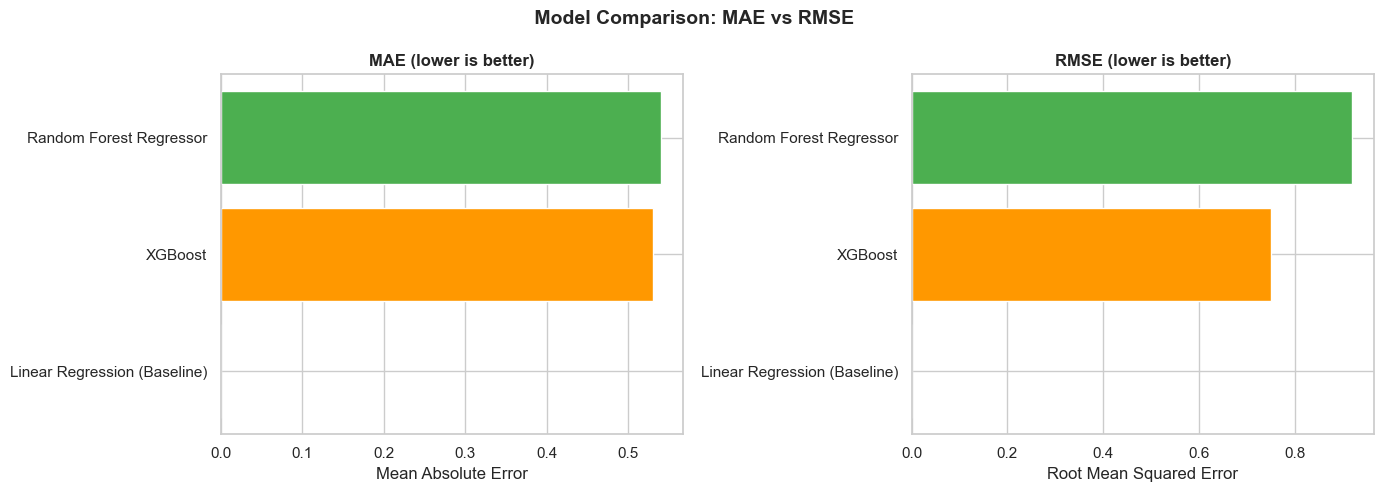

In [15]:
# ── CELL 9: Comparison Bar Chart ────────────────────────────

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#F44336', '#FF9800', '#4CAF50', '#2196F3']

# MAE
ax1.barh(results_df['model'], results_df['MAE'], color=colors[:len(results_df)])
ax1.set_title('MAE (lower is better)', fontweight='bold')
ax1.set_xlabel('Mean Absolute Error')

# RMSE
ax2.barh(results_df['model'], results_df['RMSE'], color=colors[:len(results_df)])
ax2.set_title('RMSE (lower is better)', fontweight='bold')
ax2.set_xlabel('Root Mean Squared Error')

plt.suptitle(' Model Comparison: MAE vs RMSE', fontsize=14, fontweight='bold')
plt.tight_layout()

plt.savefig('../outputs/plot7_model_comparison.png', dpi=150)

plt.show()

In [16]:
for i, v in enumerate(results_df['MAE']):
    ax1.text(v, i, f"{v:.1f}", va='center')

for i, v in enumerate(results_df['RMSE']):
    ax2.text(v, i, f"{v:.1f}", va='center')

##  Step 10: Actual vs Predicted Comparison

This visualization compares actual sales with model predictions.

### Purpose:
- Evaluate model performance visually
- Identify underfitting or overfitting
- Compare prediction accuracy across models

###  What to Look For:
- Predictions closely following actual line → good model
- Large gaps → poor performance
- Smooth vs noisy predictions → model behavior

The best model should closely track real sales trends.

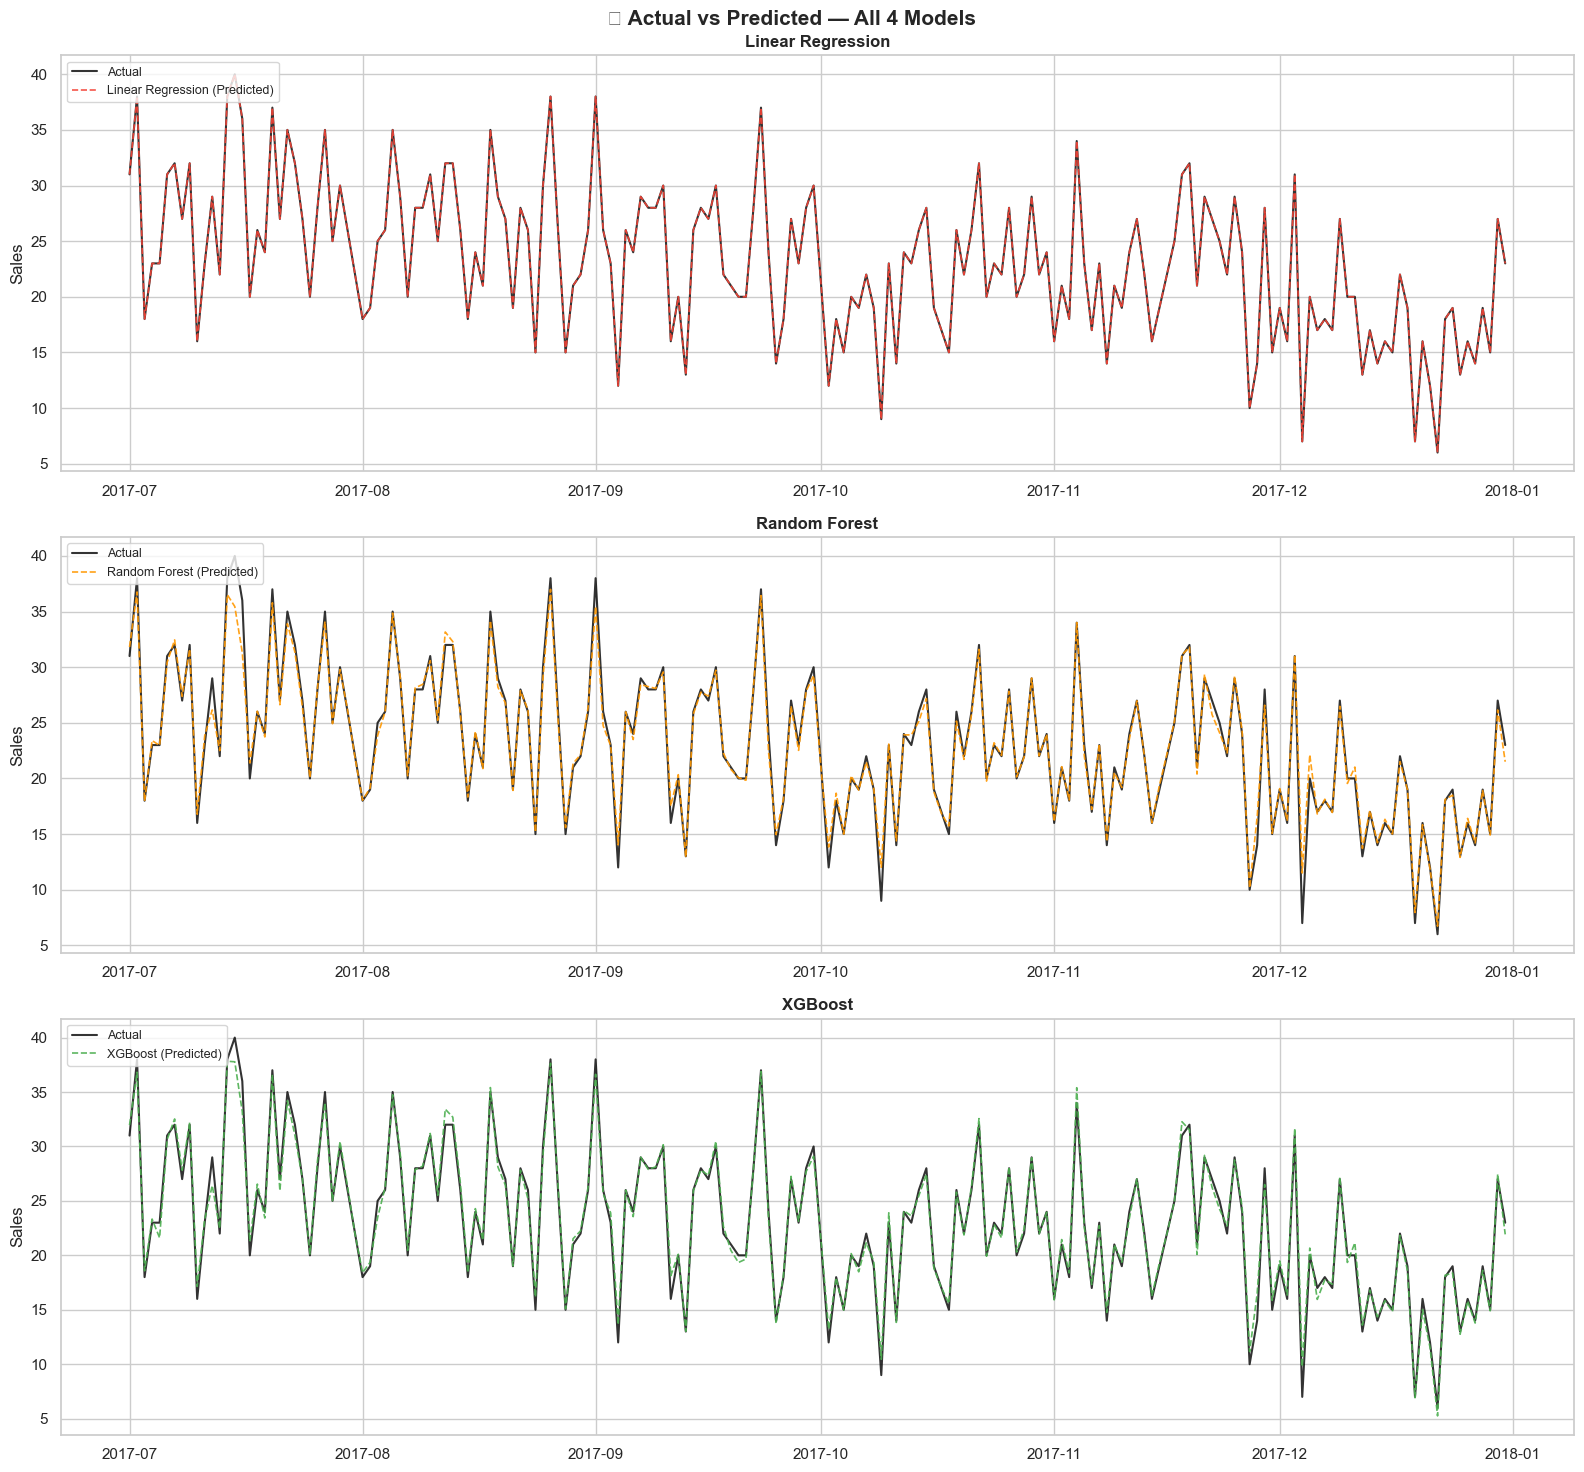

In [22]:
# ── CELL 10: Predictions vs Actuals Plot ────────────────────

fig, axes = plt.subplots(3, 1, figsize=(16, 15))

all_preds = [
    ("Linear Regression", lr_preds,  '#F44336'),
    ("Random Forest",     rf_preds,  '#FF9800'),
    ("XGBoost",           xgb_preds, '#4CAF50'),
]

for ax, (name, preds, color) in zip(axes, all_preds):

    ax.plot(test_df['date'].values, y_test.values,
            label='Actual', color='black', linewidth=1.5, alpha=0.8)

    ax.plot(test_df['date'].values, preds,
            label=f'{name} (Predicted)', color=color,
            linewidth=1.2, linestyle='--', alpha=0.9)

    ax.set_title(f'{name}', fontsize=12, fontweight='bold')
    ax.legend(loc='upper left', fontsize=9)
    ax.set_ylabel('Sales')

plt.suptitle('📈 Actual vs Predicted — All 4 Models',
             fontsize=15, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/plot8_actuals_vs_predictions.png', dpi=150)
plt.show()

##  Step 11: Save Best Model

We save the best-performing model (XGBoost) for future use.

###  Why Save the Model?
- Avoid retraining every time
- Enable deployment / predictions
- Reuse in dashboards or APIs

###  Important Practice:
- Model files (.pkl) are **NOT pushed to GitHub**
- Stored locally inside `models/` folder

In [19]:
# ── CELL 11: Save Best Model ─────────────────────────────────

import os
import pickle

# Ensure models directory exists
model_path = '../models'

if not os.path.exists(model_path):
    os.makedirs(model_path)

# Save model
with open(f'{model_path}/xgboost_best_model.pkl', 'wb') as f:
    pickle.dump(xgb, f)

print(" XGBoost model saved to models/")
print(" models/ is in .gitignore — not pushed to GitHub")

 XGBoost model saved to models/
 models/ is in .gitignore — not pushed to GitHub


In [21]:
results_df.to_csv('../outputs/final_model_results.csv', index=False)
print("Final results saved!")

Final results saved!
